# 2PLM with PyMC

2 parameters logistic model (2PLM)

$$
P(u_{ij} = 1) = \frac{1}{1+ \exp(-D a_j ( \theta_i - b_j))}
$$

- $\theta_i$: ability of respondent $i$
- $a_j$: discrimination parameter of item $j$
- $b_j$: difficulty parameter of item $j$
- $D = 1.7$: scaling constant

## Priors

$$
\theta_i \sim \mathcal{N}(0, 1), \quad
a_j \sim \text{LogNormal}(0, 0.5), \quad
b_j \sim \mathcal{N}(0, 1)
$$

Fixing $\theta \sim \mathcal{N}(0,1)$ resolves the location/scale non-identifiability of IRT models.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az

## Data Generation

Same sample data as the Stan notebook (seed=42).

In [2]:
rng = np.random.default_rng(42)

N = 100  # respondents
J = 20   # items
D = 1.7  # scaling constant

# True parameters
theta_true = rng.normal(0, 1, N)
a_true = rng.lognormal(0, 0.5, J)
b_true = rng.normal(0, 1, J)

# Generate responses
logit_p = D * a_true[None, :] * (theta_true[:, None] - b_true[None, :])
p = 1 / (1 + np.exp(-logit_p))
Y = rng.binomial(1, p).astype(int)

print(f"Response matrix shape: {Y.shape}")
print(f"Mean correct rate: {Y.mean():.3f}")
print(f"True a range: [{a_true.min():.2f}, {a_true.max():.2f}]")
print(f"True b range: [{b_true.min():.2f}, {b_true.max():.2f}]")

Response matrix shape: (100, 20)
Mean correct rate: 0.463
True a range: [0.42, 2.23]
True b range: [-1.47, 2.91]


## PyMC Model

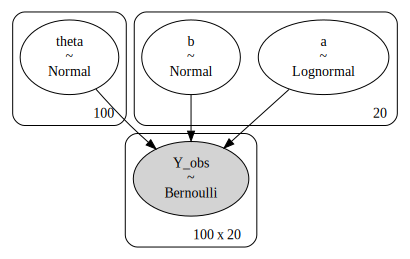

In [4]:
with pm.Model() as model_2plm:
    # Priors
    theta = pm.Normal("theta", mu=0, sigma=1, shape=N)
    a = pm.LogNormal("a", mu=0, sigma=0.5, shape=J)
    b = pm.Normal("b", mu=0, sigma=1, shape=J)

    # Linear predictor (N x J) using broadcasting
    logit_p = D * a[None, :] * (theta[:, None] - b[None, :])

    # Likelihood
    Y_obs = pm.Bernoulli("Y_obs", logit_p=logit_p, observed=Y)

pm.model_to_graphviz(model_2plm)

## Sampling

In [5]:
with model_2plm:
    idata = pm.sample(
        1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, a, b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 4 seconds.


## Results

In [6]:
az.summary(idata, var_names=["a", "b"], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[0],1.20,0.30,0.70,1.78,0.01,0.00,3131.82,3039.48,1.0
a[1],1.86,0.54,1.00,2.89,0.01,0.01,2410.12,2760.76,1.0
a[2],0.54,0.15,0.28,0.81,0.00,0.00,4329.59,3067.43,1.0
a[3],1.60,0.55,0.72,2.59,0.01,0.01,2738.16,2613.22,1.0
a[4],0.62,0.16,0.34,0.93,0.00,0.00,3728.32,3167.46,1.0
a[5],0.85,0.21,0.47,1.25,0.00,0.00,3675.00,2936.13,1.0
a[6],0.75,0.19,0.40,1.10,0.00,0.00,2934.56,2849.39,1.0
a[7],1.26,0.31,0.70,1.86,0.01,0.00,3325.05,2570.03,1.0
a[8],1.22,0.30,0.70,1.81,0.01,0.00,3124.39,2919.66,1.0
a[9],0.63,0.16,0.33,0.93,0.00,0.00,3818.49,2711.17,1.0


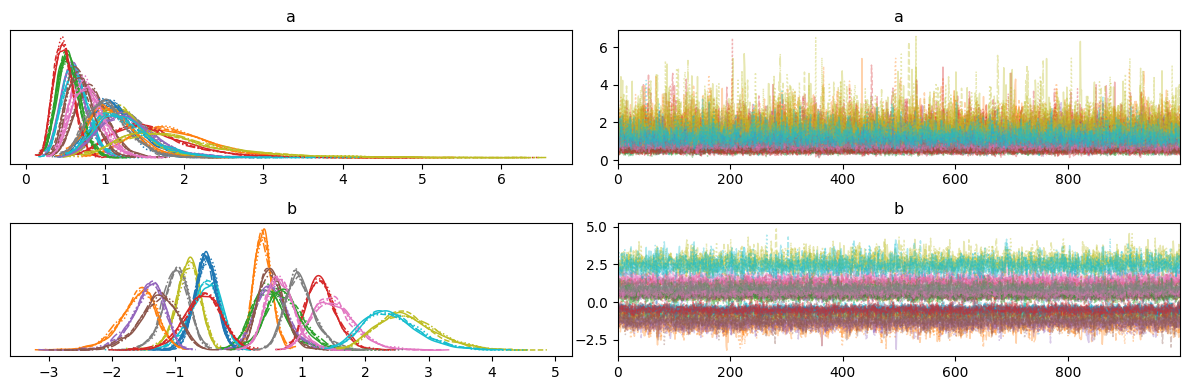

In [7]:
az.plot_trace(idata, var_names=["a", "b"], compact=True)
plt.tight_layout()
plt.show()

## Comparison: Estimated vs True Parameters

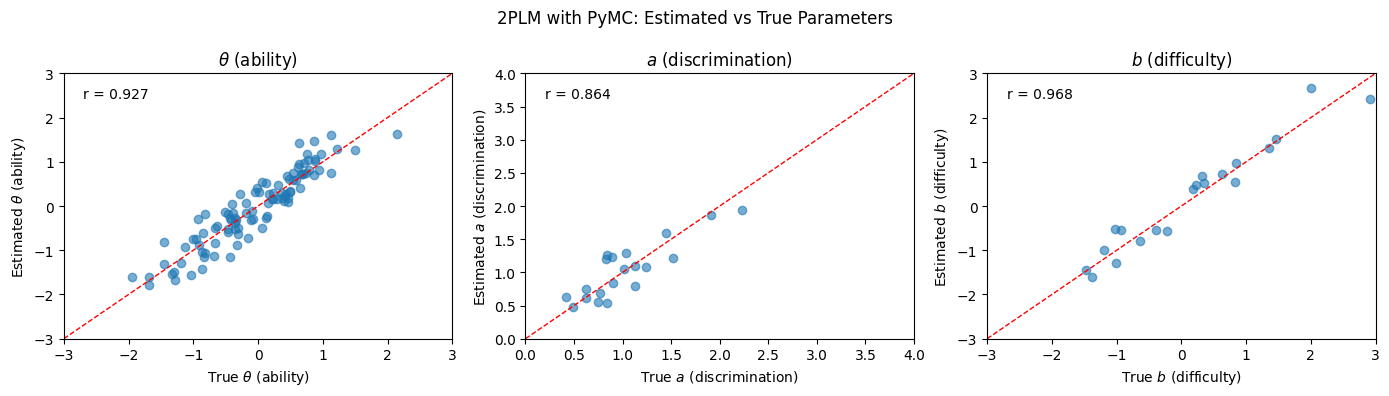

In [8]:
theta_est = idata.posterior["theta"].mean(dim=["chain", "draw"]).values
a_est = idata.posterior["a"].mean(dim=["chain", "draw"]).values
b_est = idata.posterior["b"].mean(dim=["chain", "draw"]).values

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, true_vals, est_vals, label, lim in zip(
    axes,
    [theta_true, a_true, b_true],
    [theta_est, a_est, b_est],
    [r"$\theta$ (ability)", r"$a$ (discrimination)", r"$b$ (difficulty)"],
    [(-3, 3), (0, 4), (-3, 3)],
):
    ax.scatter(true_vals, est_vals, alpha=0.6)
    ax.plot(lim, lim, "r--", lw=1)
    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ax.set_xlabel(f"True {label}")
    ax.set_ylabel(f"Estimated {label}")
    ax.set_title(label)
    corr = np.corrcoef(true_vals, est_vals)[0, 1]
    ax.text(0.05, 0.95, f"r = {corr:.3f}", transform=ax.transAxes, va="top")

plt.suptitle("2PLM with PyMC: Estimated vs True Parameters")
plt.tight_layout()
plt.show()